# PubMedQA Exploratory Data Analysis

This notebook provides the initial exploratory data analysis for examining the PubMedQA dataset.


In [1]:
%load_ext autoreload
%autoreload 2

# Use HuggingFace's datasets library to access the Emotion dataset
from datasets import load_dataset
import numpy as np
import pandas as pd


dataset = load_dataset("pubmed_qa", "pqa_labeled")

def build_context(example):
    example["combined_context"] = " ".join(example["context"]["contexts"])
    return example

dataset = dataset.map(build_context)

C:\Users\Alex\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading instructions taken from the worksheet provided.

In [2]:
df = dataset["train"].to_pandas()

# Our 3 fields
df = df[["question", "combined_context", "final_decision"]]

# renaming vars
df = df.rename(columns={
    "combined_context": "context",
    "final_decision": "label"
})

df.head()

,question,context,label
0,Do mitochondria play a role in remodelling lac...,Programmed cell death (PCD) is the regulated d...,yes
1,Landolt C and snellen e acuity: differences in...,Assessment of visual acuity depends on the opt...,no
2,"Syncope during bathing in infants, a pediatric...",Apparent life-threatening events in infants ar...,yes
3,Are the long-term results of the transanal pul...,The transanal endorectal pull-through (TERPT) ...,no
4,Can tailored interventions increase mammograph...,Telephone counseling and tailored print commun...,yes


These are the three important features.

In [3]:
print(df.shape)
print(df['label'].unique())

(1000, 3)
['yes' 'no' 'maybe']


So we have 3 distinct labels, yes no and maybe.

yes means the evidence supports the question.

no means the evidence contradicts it.

maybe means it is not so clear, or there is not enough evidence.

In [4]:
df['label'].value_counts()

label
yes      552
no       338
maybe    110
Name: count, dtype: int64

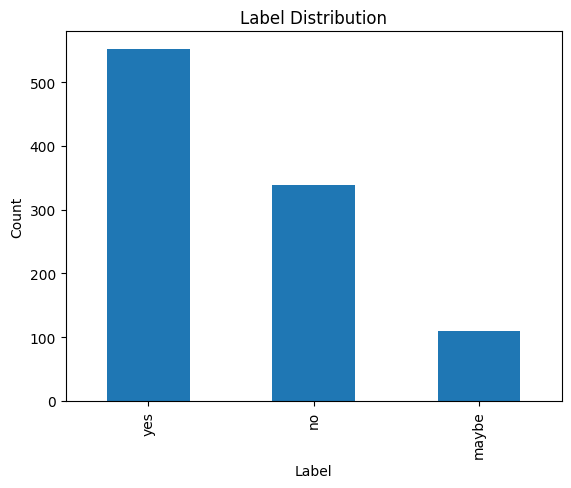

In [5]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

We can see that the data set shows a slight imbalance, with yes forming 55.2%, no forming 33.8% and maybe forming 11% of the samples.

Already, we can extract quite a lot of insights from this.

The dominance of the yes label appearing more frequently than no or maybe might bias a model toward predicting positive outcomes.

But on the opposite side, the maybe label is significantly under represented. Models can become biased towards predicting yes or no while underperforming on maybe due to limited samples. This can be especially important if maybe is a meaningful and decision critical categry, especially in medical contexts!

Practically speaking, we could also see a lower recall value for maybe, inflated accuracy if a model ignores the minority class, and decision boundary bias towards majority classes yes and no.

How should we handle this?

There are a few methods that come to mind:

Class weighting, where we simply assign a higher importance to the minority class during training. The model is penalised more for misclassifying maybe, and encourages better learning of the maybe class.

Oversampling, where we increase the number of minority samples to get a more balanced dataset.

Undersampling, where we reduce the number of majority samples to balance the distribution.

In practice, a combination of class weighting and careful evaluation using per class metrics is often preferred, as it avoids data distortion while still addressing imbalance effectively.


In [6]:
df['q_len'] = df['question'].apply(lambda x: len(x.split()))
df['context_len'] = df['context'].apply(lambda x: len(x.split()))

df[['q_len', 'context_len']].describe()

,q_len,context_len
count,1000.000000,1000.000000
mean,12.913000,200.207000
std,4.100518,51.846429
min,3.000000,49.000000
25%,10.000000,166.750000
50%,13.000000,200.500000
75%,15.000000,228.000000
max,31.000000,398.000000


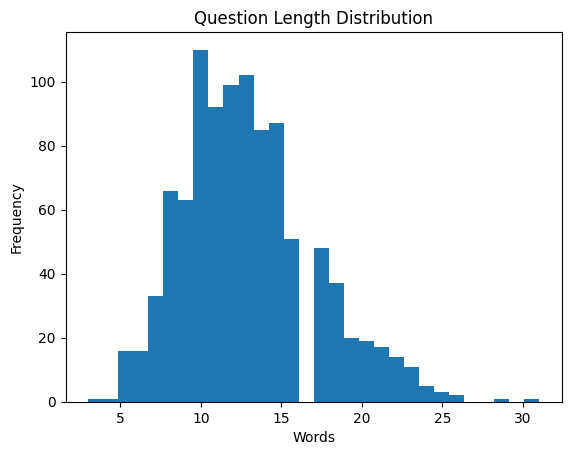

In [7]:
plt.hist(df['q_len'], bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

m

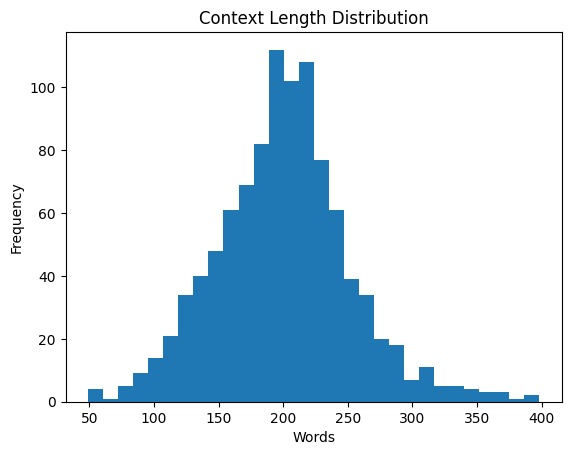

In [8]:
plt.hist(df['context_len'], bins=30)
plt.title("Context Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

There is a big disparity between question length and context length. 

With contexts being a lot larger, which hints that models need to filter out relevant information from noisy input rather than relying on shallow pattern matching.

In [9]:
df['q_start'] = df['question'].apply(lambda x: x.split()[0].lower())
df['q_start'].value_counts().head(10)

q_start
does            196
is              191
can              83
do               80
are              68
the              20
should           17
could             6
has               4
preoperative      4
Name: count, dtype: int64

When we do this kind of frequency analysis (looking at the first word of each question), a clear pattern emerges in the question set. They follow a binary question structure "is" and "does", which suggests that a classification based approach is suitable.

In [10]:
df.isnull().sum()

question       0
context        0
label          0
q_len          0
context_len    0
q_start        0
dtype: int64

It's a complete data set with no missing values. 

There is no need to impute or remove rows.

In [11]:
import re

df['has_number'] = df['context'].apply(lambda x: bool(re.search(r'\d', x)))

df.groupby('label')['has_number'].mean()

label
maybe    0.981818
no       0.982249
yes      0.981884
Name: has_number, dtype: float64

Here we are checking if a context contains numerical values. This is important as we are looking for statistics, mainly percentages and measurements. These can be harder to interpret as they add reasoning complexity, which can affect model performance.